# Strategy Comparison — Statistical Testing & Unified Learning Curves

Loads results from all 5 strategies (notebooks 06 & 07) and:
1. **Within-round learning curve**: average running-reward per step across 30 rounds — shows how fast each strategy converges to the optimal discount arm.
2. **Per-round reward distribution**: 30 independent totals per strategy — used for statistical tests.
3. **Paired t-tests**: each MAB strategy vs baseline (30 paired rounds).
4. **Arm allocation**: which discount each strategy learned to prefer.

*Prerequisites*: run `05_baseline.ipynb`, `06_mab.ipynb`, `07_linucb.ipynb` first.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import os, warnings
warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
RESULT_DIR = os.path.join(BASE_DIR, 'results')

N_ARMS         = 5
N_TRANSACTIONS = 50_000
ARM_LABELS     = ['-10%', '-5%', '0%', '+5%', '+10%']
ARM_COLORS     = ['#2166AC', '#74ADD1', '#888888', '#F46D43', '#D73027']

# Strategy registry: (file_stem, display_name, line_color, linestyle)
STRATEGIES = [
    ('baseline',           'Baseline (0%)',       '#888888', '--'),
    ('epsilon_greedy',     'ε-Greedy',            '#E8762B', '-'),
    ('ucb1',               'UCB1',                '#1C8B5A', '-'),
    ('thompson_sampling',  'Thompson Sampling',   '#9B59B6', '-'),
    ('linucb',             'LinUCB',              '#E74C3C', '-'),
]

# Load per-round result CSVs
results = {}
for stem, label, color, ls in STRATEGIES:
    path = os.path.join(RESULT_DIR, f'{stem}_results.csv')
    if os.path.exists(path):
        results[stem] = pd.read_csv(path)
        print(f'Loaded {stem:<22}  rounds={len(results[stem])}  '
              f'mean_reward={results[stem]["total_reward"].mean():,.0f}')
    else:
        print(f'MISSING (run prerequisite notebook): {path}')

# Load within-round cumulative arrays (.npy)
within = {}
for stem, *_ in STRATEGIES:
    path = os.path.join(RESULT_DIR, f'{stem}_within_round.npy')
    if os.path.exists(path):
        within[stem] = np.load(path)   # shape (30, 5000)
    else:
        print(f'MISSING within_round.npy: {stem}')

Loaded baseline                rounds=30  mean_reward=4,511,037
Loaded epsilon_greedy          rounds=30  mean_reward=4,725,412
Loaded ucb1                    rounds=30  mean_reward=4,566,352
Loaded thompson_sampling       rounds=30  mean_reward=4,689,164
Loaded linucb                  rounds=30  mean_reward=4,731,379


## 0. Booking Probability & Revenue by Discount Arm × Price Tier

Shows the model's predicted P(booked) and expected revenue under each discount arm,
broken down by price tier. Explains *why* raising prices increases total reward.

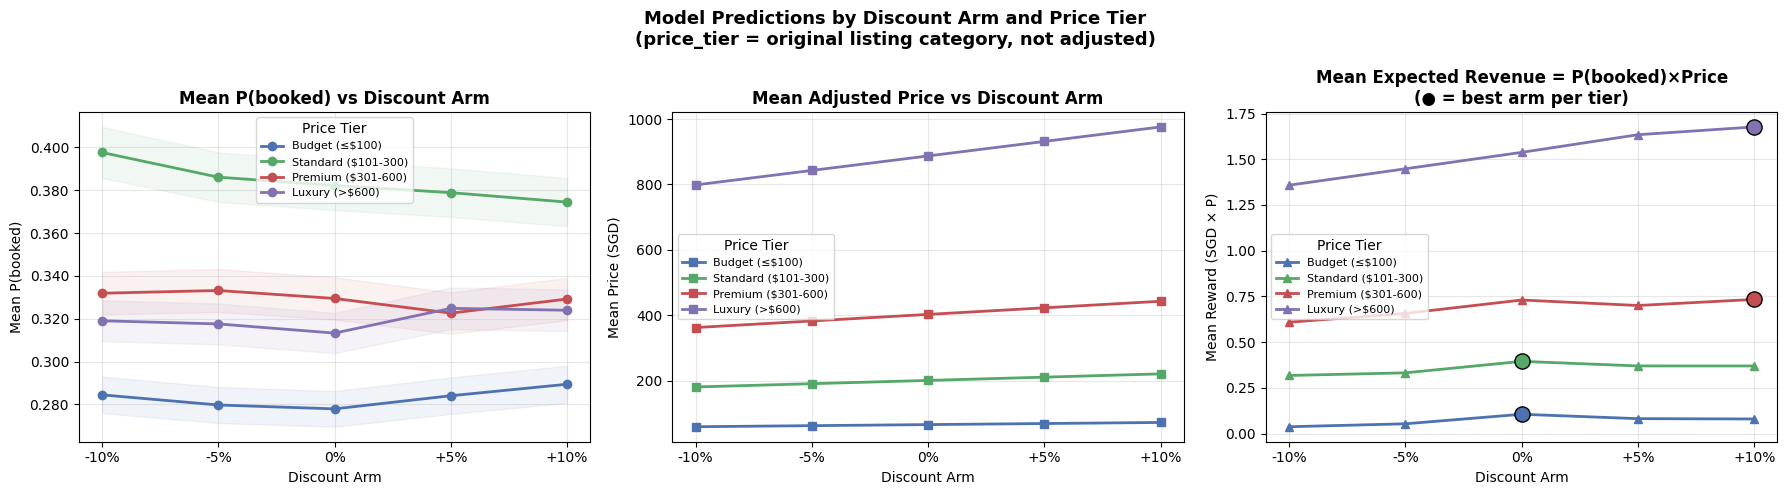


P(booked) and Revenue change: 0% → +15% by tier
Tier                          P@0%  P@+15%      ΔP    Rev@0%  Rev@+15%    ΔRev
---------------------------------------------------------------------------
Budget (≤$100)              0.2779  0.2894   +4.1%       0.1       0.1  -24.3%
Standard ($101-300)         0.3822  0.3744   -2.0%       0.4       0.4   -6.4%
Premium ($301-600)          0.3295  0.3292   -0.1%       0.7       0.7   +0.4%
Luxury (>$600)              0.3133  0.3240   +3.4%       1.5       1.7   +9.0%


In [51]:
ARM_ORDER   = ['-10%', '-5%', '0%', '+5%', '+10%']
TIER_ORDER  = ['Budget (≤$100)', 'Standard ($101-300)',
               'Premium ($301-600)', 'Luxury (>$600)']
TIER_COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
ARM_X       = list(range(len(ARM_ORDER)))

# Use a separate variable name to avoid overwriting scipy.stats
tier_stats = pd.read_csv(os.path.join(RESULT_DIR, 'tier_arm_stats.csv'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Predictions by Discount Arm and Price Tier\n'
             '(price_tier = original listing category, not adjusted)',
             fontsize=13, fontweight='bold')

# ── (1) P(booked) ────────────────────────────────────────────────────
ax = axes[0]
for tier, color in zip(TIER_ORDER, TIER_COLORS):
    sub = tier_stats[tier_stats['tier_label'] == tier].set_index('arm_label').reindex(ARM_ORDER)
    ax.plot(ARM_X, sub['mean_prob'].values, marker='o', color=color,
            linewidth=2, markersize=6, label=tier)
    ax.fill_between(ARM_X,
                    sub['mean_prob'].values * 0.97,
                    sub['mean_prob'].values * 1.03,
                    color=color, alpha=0.08)
ax.set_title('Mean P(booked) vs Discount Arm', fontweight='bold')
ax.set_xticks(ARM_X); ax.set_xticklabels(ARM_ORDER)
ax.set_xlabel('Discount Arm'); ax.set_ylabel('Mean P(booked)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.legend(fontsize=8, title='Price Tier'); ax.grid(alpha=0.3)

# ── (2) Mean adjusted price ───────────────────────────────────────────
ax = axes[1]
for tier, color in zip(TIER_ORDER, TIER_COLORS):
    sub = tier_stats[tier_stats['tier_label'] == tier].set_index('arm_label').reindex(ARM_ORDER)
    ax.plot(ARM_X, sub['mean_adj_price'].values, marker='s', color=color,
            linewidth=2, markersize=6, label=tier)
ax.set_title('Mean Adjusted Price vs Discount Arm', fontweight='bold')
ax.set_xticks(ARM_X); ax.set_xticklabels(ARM_ORDER)
ax.set_xlabel('Discount Arm'); ax.set_ylabel('Mean Price (SGD)')
ax.legend(fontsize=8, title='Price Tier'); ax.grid(alpha=0.3)

# ── (3) Expected revenue = P(booked) × price ─────────────────────────
ax = axes[2]
for tier, color in zip(TIER_ORDER, TIER_COLORS):
    sub = tier_stats[tier_stats['tier_label'] == tier].set_index('arm_label').reindex(ARM_ORDER)
    vals = sub['mean_reward'].values
    ax.plot(ARM_X, vals, marker='^', color=color, linewidth=2, markersize=6, label=tier)
    best_a = int(np.nanargmax(vals))
    ax.scatter(ARM_X[best_a], vals[best_a],
               color=color, s=120, zorder=5, edgecolors='black', linewidth=1)
ax.set_title('Mean Expected Revenue = P(booked)×Price\n(● = best arm per tier)',
             fontweight='bold')
ax.set_xticks(ARM_X); ax.set_xticklabels(ARM_ORDER)
ax.set_xlabel('Discount Arm'); ax.set_ylabel('Mean Reward (SGD × P)')
ax.legend(fontsize=8, title='Price Tier'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'tier_arm_prob_reward.png'), dpi=120)
plt.show()

# Summary table
print('\nP(booked) and Revenue change: 0% → +15% by tier')
print(f'{"Tier":<25}  {"P@0%":>7} {"P@+15%":>7} {"ΔP":>7}  {"Rev@0%":>8} {"Rev@+15%":>9} {"ΔRev":>7}')
print('-' * 75)
for tier in TIER_ORDER:
    sub = tier_stats[tier_stats['tier_label'] == tier].set_index('arm_label')
    p0, p15 = sub.loc['0%', 'mean_prob'], sub.loc['+10%', 'mean_prob']
    r0, r15 = sub.loc['0%', 'mean_reward'], sub.loc['+10%', 'mean_reward']
    print(f'{tier:<25}  {p0:>7.4f} {p15:>7.4f} {(p15-p0)/p0*100:>+6.1f}%  '
          f'{r0:>8.1f} {r15:>9.1f} {(r15-r0)/r0*100:>+6.1f}%')

## 1. Within-Round Learning Curves (All 5 Strategies)

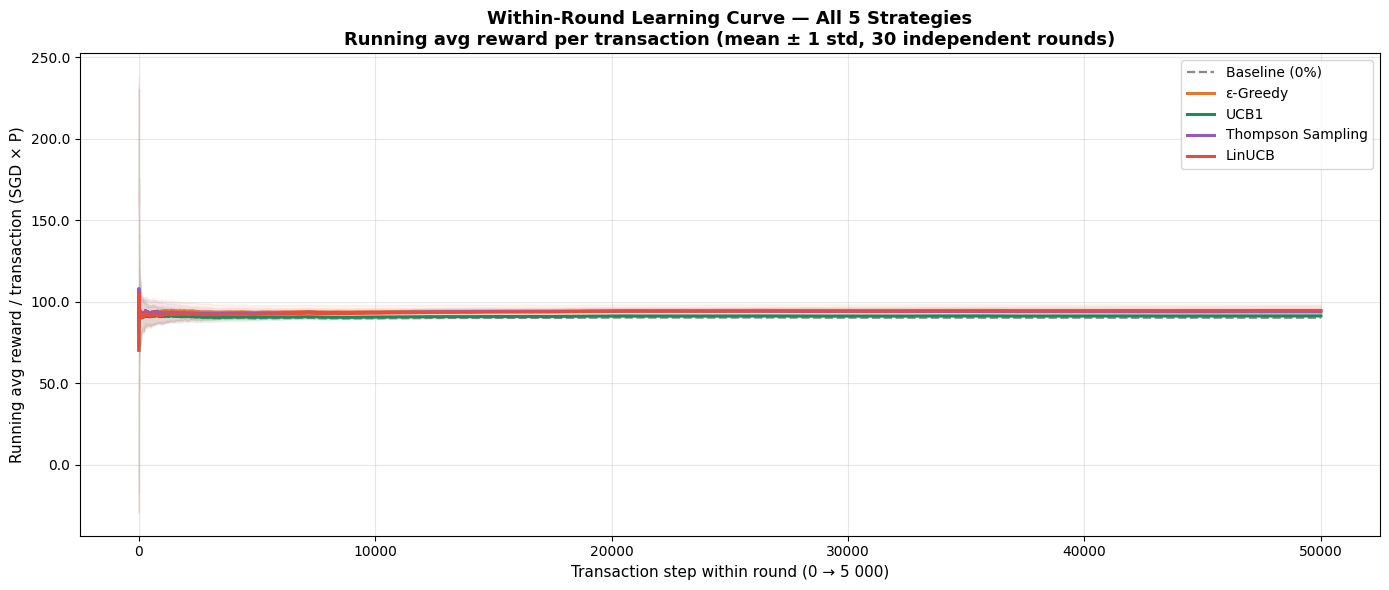

In [52]:
strat_lookup = {s[0]: s for s in STRATEGIES}
steps = np.arange(1, N_TRANSACTIONS + 1)

fig, ax = plt.subplots(figsize=(14, 6))

skipped = []
for stem, wc in within.items():
    _, label, color, ls = strat_lookup[stem]
    if wc.shape[1] != N_TRANSACTIONS:
        skipped.append(f'{stem} (shape={wc.shape}, expected (30,{N_TRANSACTIONS}))')
        continue
    running_avg  = wc / steps[np.newaxis, :]
    mean_curve   = running_avg.mean(axis=0)
    std_curve    = running_avg.std(axis=0)
    lw = 1.6 if stem == 'baseline' else 2.2
    ax.plot(steps, mean_curve, color=color, linestyle=ls, linewidth=lw, label=label)
    if stem != 'baseline':
        ax.fill_between(steps,
                        mean_curve - std_curve,
                        mean_curve + std_curve,
                        color=color, alpha=0.08)

if skipped:
    print('⚠ Shape mismatch — stale .npy from old run. Re-run 06_mab → 07_linucb first:')
    for s in skipped:
        print(f'   {s}')

ax.set_title('Within-Round Learning Curve — All 5 Strategies\n'
             'Running avg reward per transaction (mean ± 1 std, 30 independent rounds)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Transaction step within round (0 → 5 000)', fontsize=11)
ax.set_ylabel('Running avg reward / transaction (SGD × P)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_learning_curve.png'), dpi=120)
plt.show()

## 2. Per-Round Reward Distribution & Statistical Tests

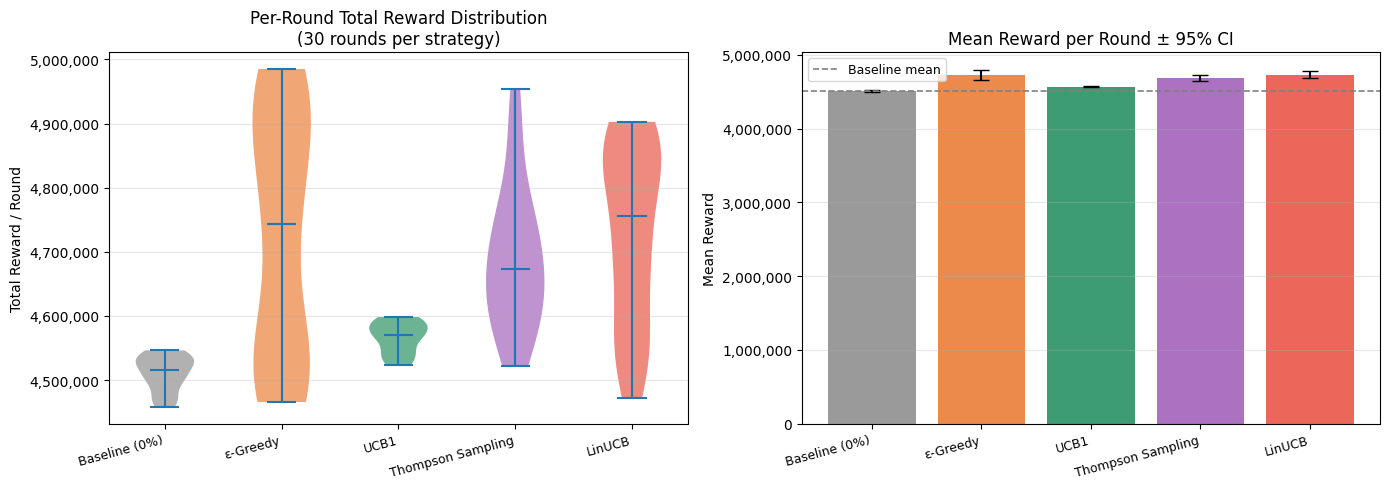

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (1) Violin plot of 30-round reward totals ──────────────────────────
ax = axes[0]
stems   = [s[0] for s in STRATEGIES if s[0] in results]
labels  = [strat_lookup[s][1] for s in stems]
colors  = [strat_lookup[s][2] for s in stems]
data    = [results[s]['total_reward'].values for s in stems]
vp = ax.violinplot(data, positions=range(len(stems)), showmedians=True, showextrema=True)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color);  body.set_alpha(0.65)
ax.set_xticks(range(len(stems)))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_title('Per-Round Total Reward Distribution\n(30 rounds per strategy)')
ax.set_ylabel('Total Reward / Round')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.3, axis='y')

# ── (2) Mean ± 95% CI bar chart ───────────────────────────────────────
ax = axes[1]
means = [results[s]['total_reward'].mean() for s in stems]
# 95% CI = t_{0.975, 29} × std / sqrt(30)
ci95  = [stats.t.ppf(0.975, df=29) * results[s]['total_reward'].std() / np.sqrt(30)
         for s in stems]
ax.bar(range(len(stems)), means, yerr=ci95, capsize=6,
       color=colors, alpha=0.85, error_kw={'linewidth': 1.5})
ax.axhline(results['baseline']['total_reward'].mean(), color='gray',
           linestyle='--', linewidth=1.2, label='Baseline mean')
ax.set_xticks(range(len(stems)))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_title('Mean Reward per Round ± 95% CI')
ax.set_ylabel('Mean Reward')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_distribution.png'), dpi=120)
plt.show()

In [54]:
# ── Paired t-tests: each MAB strategy vs baseline ─────────────────────
# Paired because round r of strategy X and round r of baseline face the same rng seed
# (same listing pool sampling), making pairs meaningful.
baseline_rewards = results['baseline']['total_reward'].values

print(f'{"Strategy":<22} {"Mean diff":>12} {"t-stat":>9} {"p-value":>10} {"Significant":>12}')
print('-' * 70)
for stem, label, color, _ in STRATEGIES:
    if stem == 'baseline' or stem not in results:
        continue
    mab_rewards = results[stem]['total_reward'].values
    t_stat, p_val = stats.ttest_rel(mab_rewards, baseline_rewards)
    mean_diff = mab_rewards.mean() - baseline_rewards.mean()
    sig = '*** p<.001' if p_val < 0.001 else ('** p<.01' if p_val < 0.01
           else ('* p<.05' if p_val < 0.05 else 'n.s.'))
    print(f'{label:<22} {mean_diff:>+12,.0f} {t_stat:>9.3f} {p_val:>10.4f} {sig:>12}')

Strategy                  Mean diff    t-stat    p-value  Significant
----------------------------------------------------------------------
ε-Greedy                   +214,375     6.118     0.0000   *** p<.001
UCB1                        +55,315    31.373     0.0000   *** p<.001
Thompson Sampling          +178,128     8.693     0.0000   *** p<.001
LinUCB                     +220,342     8.327     0.0000   *** p<.001


## 3. Arm Allocation Comparison

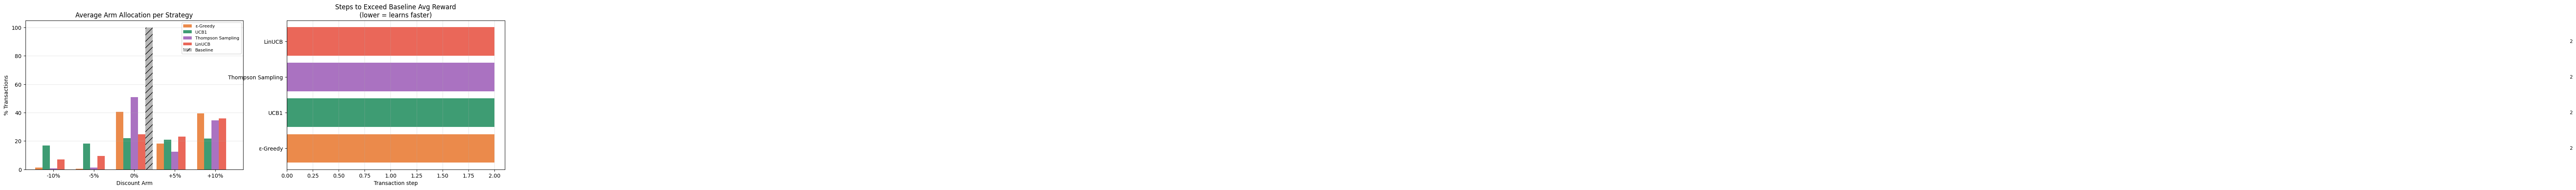

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── (1) Avg arm % per strategy (bar chart) ────────────────────────────
ax = axes[0]
mab_stems = [s[0] for s in STRATEGIES if s[0] != 'baseline' and s[0] in results
             and f'n_arm_0' in results[s[0]].columns]
x_pos   = np.arange(N_ARMS)
bar_w   = 0.18
for i, stem in enumerate(mab_stems):
    df_r = results[stem]
    total_n = sum(df_r[f'n_arm_{a}'].mean() for a in range(N_ARMS))
    pcts = [df_r[f'n_arm_{a}'].mean() / total_n * 100 for a in range(N_ARMS)]
    _, label, color, _ = strat_lookup[stem]
    ax.bar(x_pos + i * bar_w, pcts, bar_w, label=label, color=color, alpha=0.85)
# Baseline: all in arm 2
baseline_pcts = [0, 0, 100, 0, 0]
ax.bar(x_pos + len(mab_stems) * bar_w, baseline_pcts, bar_w,
       label='Baseline', color='#888888', alpha=0.6, hatch='//')
ax.set_title('Average Arm Allocation per Strategy')
ax.set_xticks(x_pos + bar_w * (len(mab_stems)) / 2)
ax.set_xticklabels(ARM_LABELS)
ax.set_xlabel('Discount Arm')
ax.set_ylabel('% Transactions')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# ── (2) Learning speed: step at which running avg first exceeds baseline mean ──
ax = axes[1]
b_final_avg = (baseline_rewards.mean() / N_TRANSACTIONS)
steps = np.arange(1, N_TRANSACTIONS + 1)
crossover_steps = {}
for stem, wc in within.items():
    if stem == 'baseline':
        continue
    mean_ra = (wc / steps[np.newaxis, :]).mean(axis=0)
    crossed = np.where(mean_ra > b_final_avg)[0]
    crossover_steps[stem] = crossed[0] + 1 if len(crossed) else None

stems_c  = [s for s in crossover_steps if crossover_steps[s] is not None]
values_c = [crossover_steps[s] for s in stems_c]
labels_c = [strat_lookup[s][1] for s in stems_c]
colors_c = [strat_lookup[s][2] for s in stems_c]
ax.barh(labels_c, values_c, color=colors_c, alpha=0.85)
ax.set_title('Steps to Exceed Baseline Avg Reward\n(lower = learns faster)')
ax.set_xlabel('Transaction step')
ax.grid(alpha=0.3, axis='x')
for i, v in enumerate(values_c):
    ax.text(v + 20, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_arm_allocation.png'), dpi=120)
plt.show()

## 4. Summary Table

In [56]:
summary_rows = []
for stem, label, color, _ in STRATEGIES:
    if stem not in results:
        continue
    df_r  = results[stem]
    mean  = df_r['total_reward'].mean()
    std   = df_r['total_reward'].std()
    ci95  = stats.t.ppf(0.975, df=29) * std / np.sqrt(30)
    diff  = mean - baseline_rewards.mean()
    diff_pct = diff / baseline_rewards.mean() * 100
    if stem != 'baseline':
        t_stat, p_val = stats.ttest_rel(df_r['total_reward'].values, baseline_rewards)
        sig = ('***' if p_val < 0.001 else '**' if p_val < 0.01
               else '*' if p_val < 0.05 else 'n.s.')
    else:
        t_stat, p_val, sig = None, None, '—'
    summary_rows.append({
        'Strategy':    label,
        'Mean/round':  f'{mean:,.0f}',
        'Std':         f'{std:,.0f}',
        '95% CI ±':    f'{ci95:,.0f}',
        'vs Baseline': f'{diff_pct:+.2f}%' if stem != 'baseline' else '—',
        'p-value':     f'{p_val:.4f}' if p_val is not None else '—',
        'Sig.':        sig,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(RESULT_DIR, 'comparison_summary.csv'), index=False)
print('\nSaved: comparison_summary.csv')

         Strategy Mean/round     Std 95% CI ± vs Baseline p-value Sig.
    Baseline (0%)  4,511,037  27,290   10,190           —       —    —
         ε-Greedy  4,725,412 190,961   71,306      +4.75%  0.0000  ***
             UCB1  4,566,352  24,415    9,117      +1.23%  0.0000  ***
Thompson Sampling  4,689,164 111,751   41,729      +3.95%  0.0000  ***
           LinUCB  4,731,379 137,840   51,470      +4.88%  0.0000  ***

Saved: comparison_summary.csv


## 5. Arm Selection by Price Tier

For each strategy, what discount arm did it choose — broken down by the listing's price tier?  
This reveals whether strategies learn **tier-specific** pricing logic or apply a uniform rule.

Building tier sequence matrix...
Done.


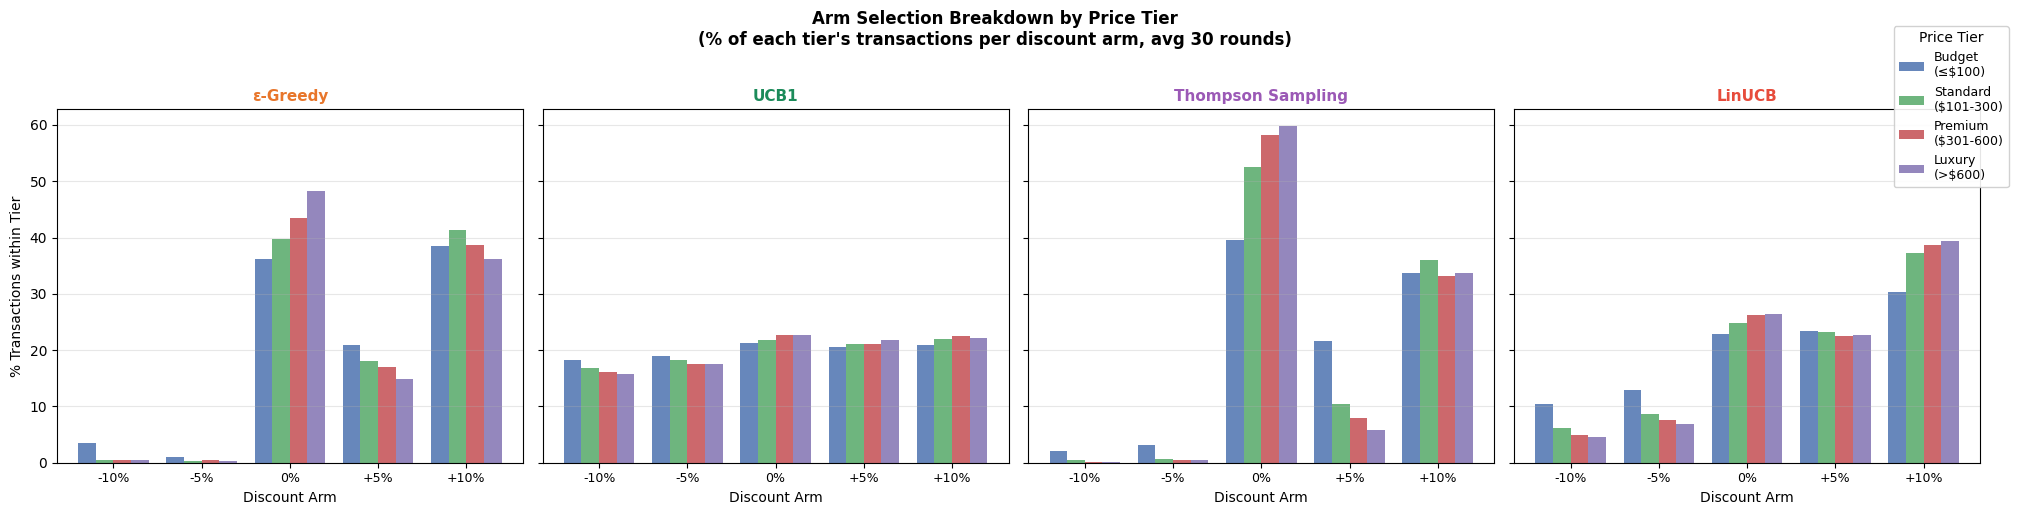

In [57]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

# ── Reconstruct row-tier sequence using the same stratified sampling as 05/06/07 ──
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed_data.csv')
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw = df_raw.dropna(subset=['price_tier', 'price_listing']).copy()
df_raw['price_tier'] = df_raw['price_tier'].astype(int)
row_tiers   = df_raw['price_tier'].values
n_rows_raw  = len(row_tiers)

SEED_BASE_       = 42
N_ROUNDS_        = 30
N_TRANSACTIONS_  = 50_000
N_TIERS_         = 4

tier_pool_idx = {t: np.where(row_tiers == t)[0] for t in range(N_TIERS_)}
total_r       = sum(len(v) for v in tier_pool_idx.values())
tier_props_   = {t: len(v) / total_r for t, v in tier_pool_idx.items()}
tier_ns_      = {t: int(np.floor(tier_props_[t] * N_TRANSACTIONS_)) for t in range(N_TIERS_)}
tier_ns_[max(tier_props_, key=tier_props_.get)] += N_TRANSACTIONS_ - sum(tier_ns_.values())

def _sample_round_indices(round_idx):
    seed = SEED_BASE_ + round_idx
    idx_list = []
    for t in range(N_TIERS_):
        rs = np.random.RandomState(seed)
        pool = tier_pool_idx[t]
        idx_list.extend(pool[rs.choice(len(pool), size=tier_ns_[t], replace=True)])
    return np.array(idx_list)

# Precompute tier label for every (round, step) — same across all strategies
print('Building tier sequence matrix...')
tier_seq = np.zeros((N_ROUNDS_, N_TRANSACTIONS_), dtype=np.int8)
for r in range(N_ROUNDS_):
    tier_seq[r] = row_tiers[_sample_round_indices(r)]
print('Done.')

# ── Load arm_history for each MAB strategy ────────────────────────────
TIER_NAMES_  = ['Budget\n(≤$100)', 'Standard\n($101-300)', 'Premium\n($301-600)', 'Luxury\n(>$600)']
ARM_LABELS_  = ['-10%', '-5%', '0%', '+5%', '+10%']
N_ARMS_      = 5
tier_colors_ = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

MAB_STRATEGIES = [
    ('epsilon_greedy',    'ε-Greedy',          '#E8762B'),
    ('ucb1',              'UCB1',              '#1C8B5A'),
    ('thompson_sampling', 'Thompson Sampling', '#9B59B6'),
    ('linucb',            'LinUCB',            '#E74C3C'),
]

arm_histories = {}
for stem, label, color in MAB_STRATEGIES:
    path = os.path.join(RESULT_DIR, f'{stem}_arm_history.npy')
    if os.path.exists(path):
        arm_histories[stem] = np.load(path)   # (30, 5000) int8
    else:
        print(f'Missing: {path}  — re-run 06/07')

# ── Compute tier × arm allocation matrix per strategy ─────────────────
def compute_tier_arm(arm_hist):
    """Returns (N_TIERS, N_ARMS) matrix: % of each tier's transactions going to each arm."""
    mat = np.zeros((N_TIERS_, N_ARMS_))
    for t in range(N_TIERS_):
        mask  = (tier_seq == t)
        total = mask.sum()
        for a in range(N_ARMS_):
            mat[t, a] = (arm_hist[mask] == a).sum() / total * 100
    return mat

# ── Plot ───────────────────────────────────────────────────────────────
n_strats = len(arm_histories)
fig, axes = plt.subplots(1, n_strats, figsize=(5 * n_strats, 5), sharey=True)
if n_strats == 1:
    axes = [axes]

x    = np.arange(N_ARMS_)
bar_w = 0.20

for ax, (stem, label, color) in zip(axes, MAB_STRATEGIES):
    if stem not in arm_histories:
        continue
    mat = compute_tier_arm(arm_histories[stem])   # (4, 5)
    for t in range(N_TIERS_):
        ax.bar(x + t * bar_w, mat[t], bar_w, label=TIER_NAMES_[t],
               color=tier_colors_[t], alpha=0.85)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(x + bar_w * (N_TIERS_ - 1) / 2)
    ax.set_xticklabels(ARM_LABELS_, fontsize=9)
    ax.set_xlabel('Discount Arm')
    ax.grid(alpha=0.3, axis='y')
    if ax is axes[0]:
        ax.set_ylabel('% Transactions within Tier')

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, title='Price Tier', loc='upper right',
           bbox_to_anchor=(1.01, 1), fontsize=9, framealpha=0.9)
fig.suptitle('Arm Selection Breakdown by Price Tier\n'
             '(% of each tier\'s transactions per discount arm, avg 30 rounds)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_tier_arm.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Soft-Constrained MAB — Lagrangian Penalty Results

Results from `09_constrained_mab.ipynb`: Thompson Sampling with soft occupancy penalty instead of hard binary zeroing.

**Formulation:**  
$$r_{\text{soft}}(a, i) = \text{GMV}(a,i) - \lambda \cdot \max(0,\; 0.60 - p_a^i/p_0^i) \cdot \text{price}_i$$

- $\lambda = 0$: unconstrained GMV maximization  
- $\lambda \to \infty$: equivalent to hard binary constraint (matching 06_mab.ipynb)

**Academic grounding:** Pacchiano et al. (2021) *Stochastic Bandits with Linear Constraints* (AISTATS); Badanidiyuru et al. (2013) *Bandits with Knapsacks* (NeurIPS).

In [58]:
import glob

# ── Load soft-constraint results saved by 09_constrained_mab.ipynb ───────────
LAMBDA_VALS  = [0.0, 0.5, 1.0, 2.0, 5.0, float('inf')]
LAMBDA_NAMES = ['λ=0 (no constraint)', 'λ=0.5', 'λ=1', 'λ=2', 'λ=5', 'λ=∞ (hard)']
LAMBDA_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#888888']

soft_results = {}
for lam, lname in zip(LAMBDA_VALS, LAMBDA_NAMES):
    safe = lname.replace('=', '').replace(' ', '_').replace('(', '').replace(')', '').replace('/', '').replace('∞','inf')
    fpath = os.path.join(RESULT_DIR, f'constrained_ts_{safe}_results.csv')
    if os.path.exists(fpath):
        soft_results[lam] = pd.read_csv(fpath)
        print(f'Loaded {lname}: mean_GMV={soft_results[lam]["total_gmv"].mean():>12,.0f}  '
              f'viol_rate={soft_results[lam]["viol_rate"].mean():.4f}')
    else:
        print(f'[Missing] {lname} — run 09_constrained_mab.ipynb first')

if soft_results:
    # ── Pareto frontier plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Soft-Constrained Thompson Sampling — Pareto Frontier\n'
                 'Agent learns from: GMV − λ · max(0, 0.60 − occ_ratio) · price',
                 fontsize=12, fontweight='bold')

    ax = axes[0]
    loaded_lams = [l for l in LAMBDA_VALS if l in soft_results]
    viol_means = [soft_results[l]['viol_rate'].mean() for l in loaded_lams]
    gmv_means  = [soft_results[l]['total_gmv'].mean()  for l in loaded_lams]
    viol_stds  = [soft_results[l]['viol_rate'].std()   for l in loaded_lams]
    gmv_stds   = [soft_results[l]['total_gmv'].std()   for l in loaded_lams]
    colors_used = [LAMBDA_COLORS[LAMBDA_VALS.index(l)] for l in loaded_lams]
    names_used  = [LAMBDA_NAMES[LAMBDA_VALS.index(l)]  for l in loaded_lams]

    ax.plot([v * 100 for v in viol_means], gmv_means, color='gray',
            linestyle='--', linewidth=1, alpha=0.5, zorder=1)
    for i, (lam, lname) in enumerate(zip(loaded_lams, names_used)):
        ax.errorbar(viol_means[i] * 100, gmv_means[i],
                    xerr=viol_stds[i] * 100, yerr=gmv_stds[i],
                    fmt='o', color=colors_used[i], markersize=10,
                    linewidth=2, capsize=4, label=lname, zorder=5)

    b_mean = baseline_df['total_reward'].mean()
    ax.axhline(b_mean, color='black', linestyle=':', linewidth=1.5, alpha=0.7,
               label=f'Baseline ({b_mean:,.0f})')

    # Mark the hard-constraint TS from 06 for comparison
    if 'thompson_sampling' in all_dfs:
        ts_hard = all_dfs['thompson_sampling']['total_reward'].mean()
        ax.axhline(ts_hard, color='purple', linestyle='-.', linewidth=1.5, alpha=0.7,
                   label=f'Hard-constraint TS ({ts_hard:,.0f})')

    ax.set_xlabel('Mean Occupancy Violation Rate (% transactions)', fontsize=11)
    ax.set_ylabel('Mean Total GMV per Round (SGD)', fontsize=11)
    ax.set_title('Pareto Frontier: GMV vs Occupancy Violations', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Summary bar chart ──────────────────────────────────────────────
    ax2 = axes[1]
    labels = names_used
    gmv_vs_base = [(g - b_mean) / b_mean * 100 for g in gmv_means]
    bar_colors = [c if vr < 0.01 else '#aaaaaa' for c, vr in zip(colors_used, viol_means)]
    bars = ax2.barh(labels, gmv_vs_base, color=bar_colors, alpha=0.85, height=0.6)
    ax2.axvline(0, color='black', linewidth=1)
    for bar, vr in zip(bars, viol_means):
        ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'viol={vr:.2%}', va='center', fontsize=8)
    ax2.set_xlabel('GMV vs Baseline (%)', fontsize=11)
    ax2.set_title('GMV Uplift by λ\n(gray = violation rate ≥ 1%)', fontsize=11)
    ax2.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'comparison_soft_constraint.png'), dpi=120)
    plt.show()
else:
    print('No soft-constraint results found. Run 09_constrained_mab.ipynb first.')

[Missing] λ=0 (no constraint) — run 09_constrained_mab.ipynb first
[Missing] λ=0.5 — run 09_constrained_mab.ipynb first
[Missing] λ=1 — run 09_constrained_mab.ipynb first
[Missing] λ=2 — run 09_constrained_mab.ipynb first
[Missing] λ=5 — run 09_constrained_mab.ipynb first
[Missing] λ=∞ (hard) — run 09_constrained_mab.ipynb first
No soft-constraint results found. Run 09_constrained_mab.ipynb first.
